In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

params = {
    'figure.figsize': (3, 4),       # Figure size in inches
    'figure.dpi': 300,               # Resolution in dots per inch
    'axes.labelsize': 7,            # Font size of the axes labels
    'axes.titlesize': 7,            # Font size of the subplot titles
    'axes.titlepad': 10,             # Spacing between the subplot title and the plot
    'axes.linewidth': .5,           # Width of the axis lines
    'axes.grid': False,              # Display grid lines
    'axes.grid.axis': 'both',        # Display grid lines for both major and minor ticks
    'grid.alpha': 0.5,               # Transparency of the grid lines
    'grid.linewidth': 0.5,           # Width of the grid lines
    'xtick.labelsize': 7,           # Font size of the x-axis tick labels
    'ytick.labelsize': 7,           # Font size of the y-axis tick labels
    'xtick.major.size': 3,           # Length of the major x-axis ticks in points
    'xtick.major.width': .5,        # Width of the major x-axis ticks
    'ytick.major.size': 3,           # Length of the major y-axis ticks in points
    'ytick.major.width': .5,        # Width of the major y-axis ticks
    'xtick.minor.size': 2,           # Length of the minor x-axis ticks in points
    'xtick.minor.width': .5,        # Width of the minor x-axis ticks
    'ytick.minor.size': 2,           # Length of the minor y-axis ticks in points
    'ytick.minor.width': .5,        # Width of the minor y-axis ticks
    'xtick.direction': 'in',         # Direction of the x-axis ticks ('in', 'out', or 'inout')
    'ytick.direction': 'in',         # Direction of the y-axis ticks ('in', 'out', or 'inout')
    'legend.fontsize': 7,           # Font size of the legend
    'legend.frameon': True,          # Whether to draw a frame around the legend
    'legend.facecolor': 'inherit',   # Background color of the legend
    'legend.edgecolor': '0.8',       # Edge color of the legend
    'legend.framealpha': 0.8,        # Transparency of the legend frame
    'legend.loc': 'best',            # Location of the legend ('best', 'upper right', 'upper left', 'lower left', etc.)
    'legend.title_fontsize': 7,     # Font size of the legend title
    'svg.fonttype': 'none'           # Output font type for PDF files
}

plt.rcParams.update(params)

/home/jcthompson5@ad.wisc.edu/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
species = ['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs', 'CHabs',
           'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs']
controls = ['AcGum', 'ArGal', 'Inulin', 'Pectin', 'Starch', 'Xylan']
fibers = ['acgum', 'argal', 'inulin', 'pectin', 'starch', 'xylan']

In [3]:
# instantiate a dictionary to keep interaction pairs for each fiber
sp_int_dict = {}

# for each individual fiber
for fiber, control in zip(fibers, controls):
    
    # for each receiving species 
    for i, sp_i in enumerate(species):
        
        # import dataframe of values for receiving species
        sp_df = pd.read_csv(f"community_shap/{sp_i}_shap.csv")
        
        # for each affector species
        for j, sp_j in enumerate(species):
            
            # dataframe with fiber, sp_i, and sp_j present
            int_ij = sp_df[(sp_df[control]==1) & (sp_df[sp_i]>0) & (sp_df[sp_j]>0)][f'{sp_i}<--{sp_j}'].values
            
            # save interaction values
            sp_int_dict[f'{fiber}_{sp_i}<--{sp_j}'] = int_ij

In [4]:
# for each fiber
k = 1
for fiber in fibers:

    # matrix of comm interactions
    comm_interactions = np.zeros([len(species), len(species)])

    for i, sp_i in enumerate(species):

        for j, sp_j in enumerate(species):

            if i != j:

                # community terms 
                comm_terms = sp_int_dict[f'{fiber}_{sp_i}<--{sp_j}']
                comm_interactions[i, j]  = np.mean(comm_terms)
                
    # save values
    pair_df = pd.DataFrame()
    pair_df[species] = comm_interactions
    pair_df.to_csv(f"{fiber}_species_net_avg.csv", index=False)

In [5]:
pair_df

,ACabs,BAabs,BHabs,BLabs,BUabs,CAabs,CCabs,CHabs,DFabs,ELabs,ERabs,FPabs,PCabs,PJabs,RIabs
0,0.000000,0.014134,0.001889,-0.002317,0.007059,-0.003494,-0.005919,0.001420,0.001171,-0.012064,-0.012025,0.000171,0.002196,-0.000936,-0.000516
1,0.001024,0.000000,0.003605,-0.006428,-0.021815,-0.005544,-0.009030,-0.007235,0.000942,0.004798,-0.005034,-0.004241,-0.003478,-0.003818,-0.000398
2,-0.005663,-0.022058,0.000000,-0.012839,0.002740,-0.001557,-0.003351,-0.000955,-0.000922,0.005724,-0.009582,-0.002434,-0.008467,-0.001163,-0.010400
3,-0.005071,-0.002181,0.001216,0.000000,0.008132,0.000592,0.003095,-0.004766,-0.000970,-0.005182,-0.003579,-0.000943,-0.000743,-0.002947,0.002096
4,0.028852,-0.081296,0.002063,0.000557,0.000000,-0.012301,0.016781,0.024193,0.006314,0.078064,-0.014366,0.002127,0.025097,-0.003245,-0.029811
5,0.001995,0.006164,-0.000925,0.001571,0.015233,0.000000,-0.015032,-0.005305,-0.001492,-0.030346,-0.001045,-0.006660,-0.000822,-0.001577,0.015525
6,-0.004217,-0.015967,-0.004506,-0.004843,-0.002254,-0.012018,0.000000,0.001084,0.000090,0.008800,-0.010013,0.003453,-0.005988,-0.000706,-0.001241
7,-0.010984,-0.011676,-0.001331,-0.007394,0.004172,-0.006435,-0.007153,0.000000,0.000577,0.001311,-0.007905,-0.004651,-0.008334,-0.003382,-0.013738
8,0.002604,0.008563,-0.005223,-0.004322,0.018545,-0.010242,-0.013478,0.007214,0.000000,0.004693,-0.008152,0.001197,0.006695,-0.000045,-0.006846
9,0.002537,-0.020822,-0.000069,0.008716,-0.025105,-0.001825,-0.017586,0.022484,0.004854,0.000000,-0.003657,-0.002788,0.006380,-0.008508,-0.019002


In [6]:
species = ['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs', 'CHabs',
           'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs']
species = [s.split("abs")[0] for s in species]

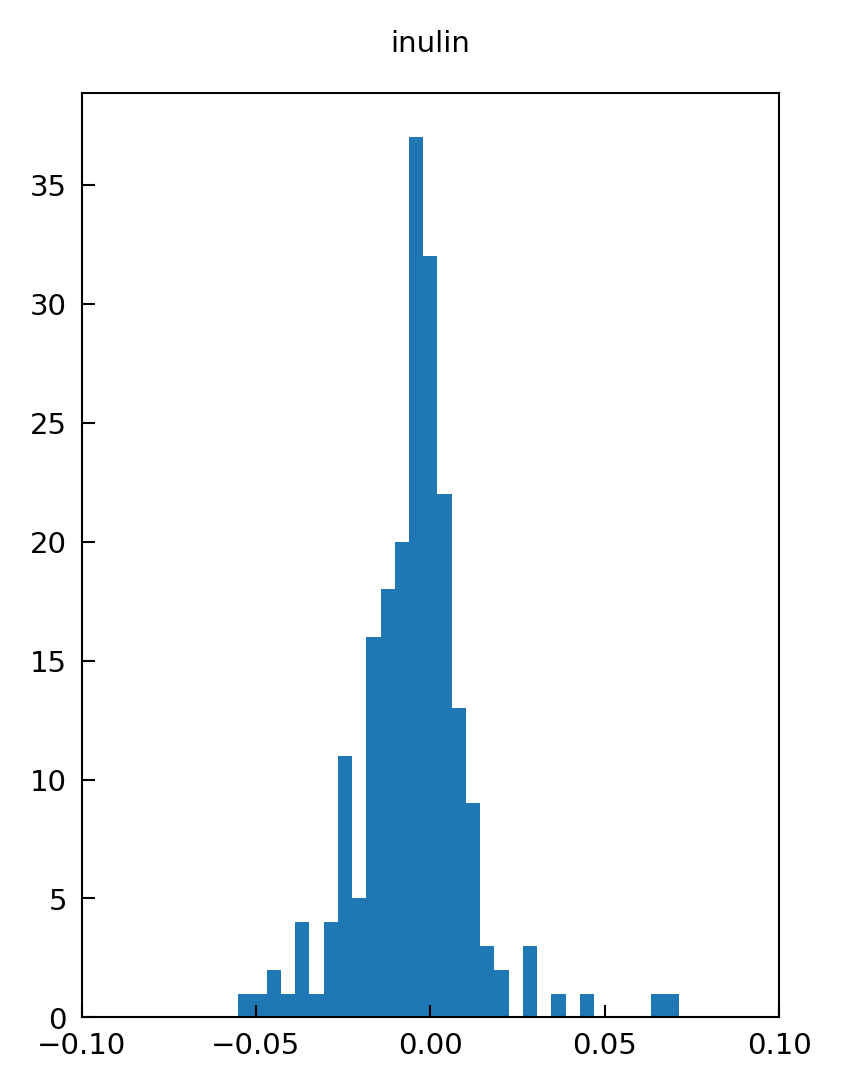

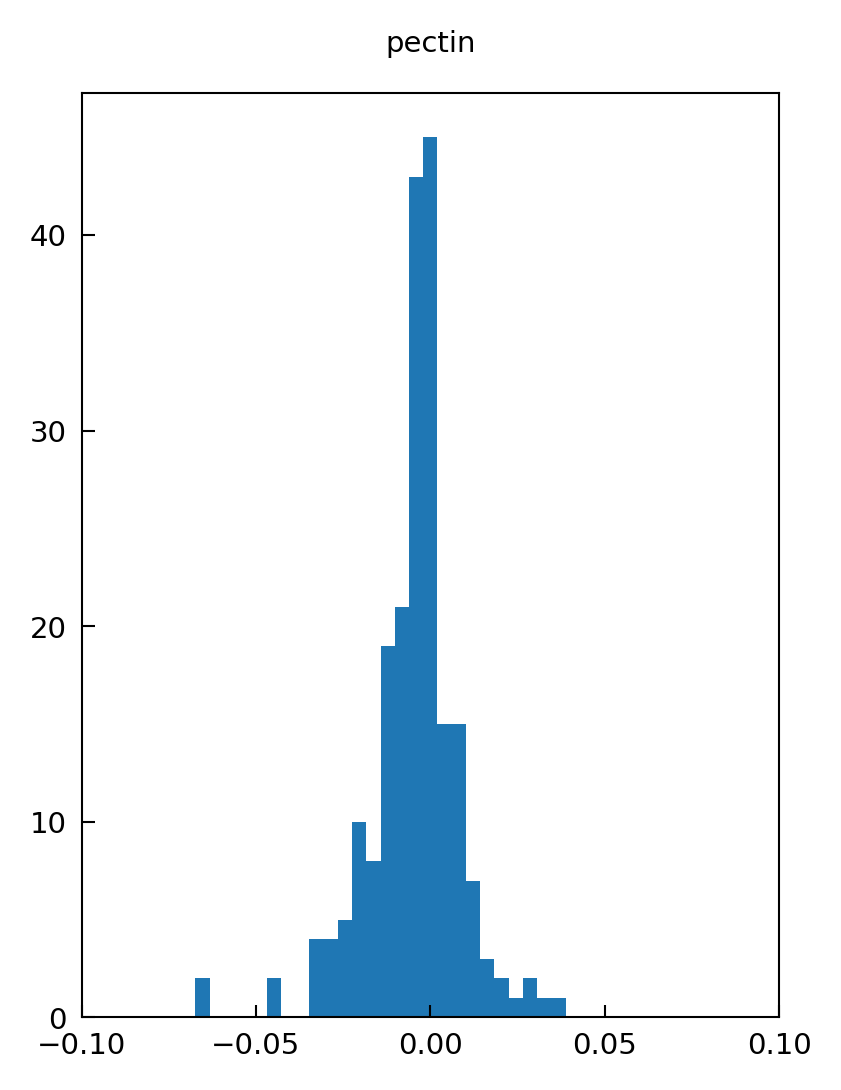

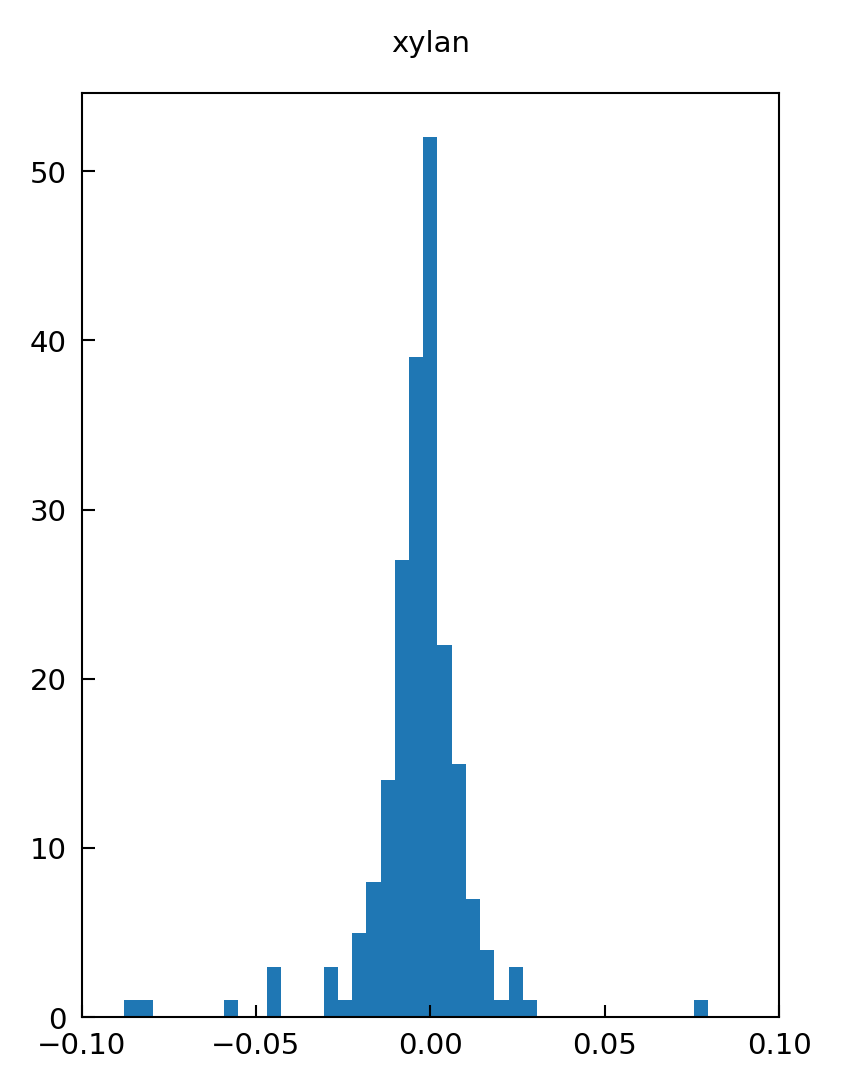

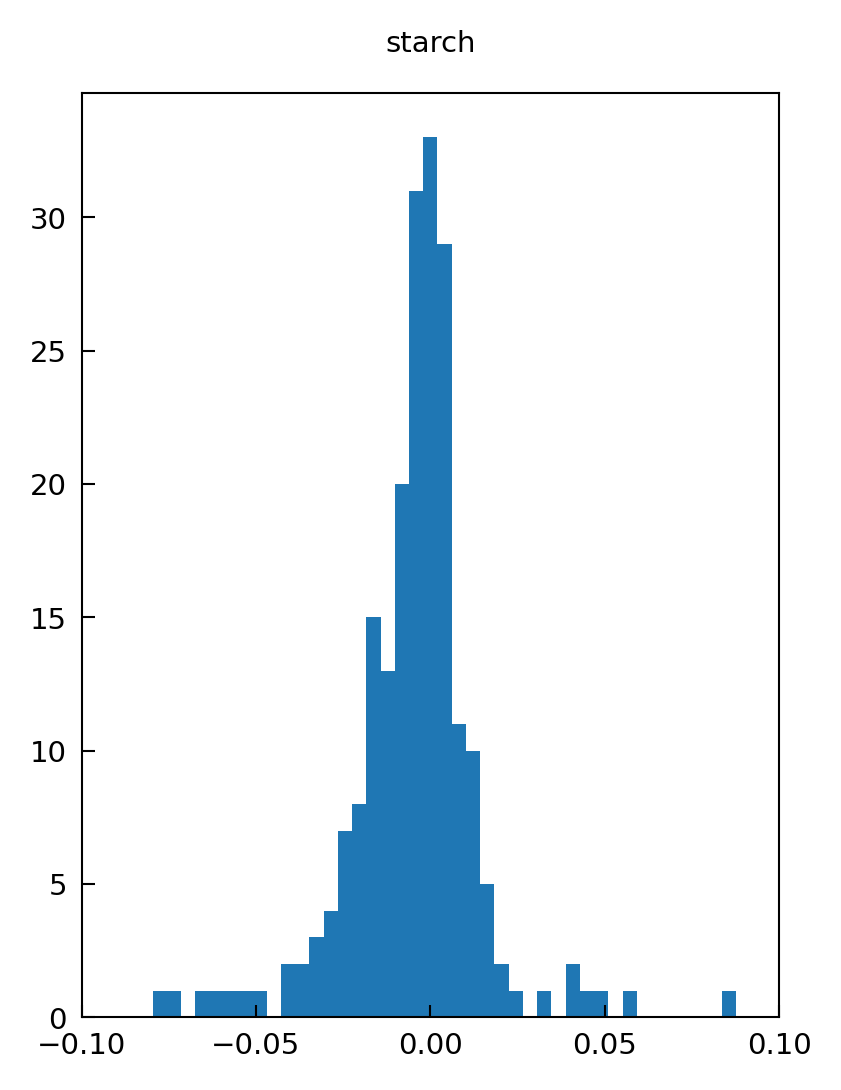

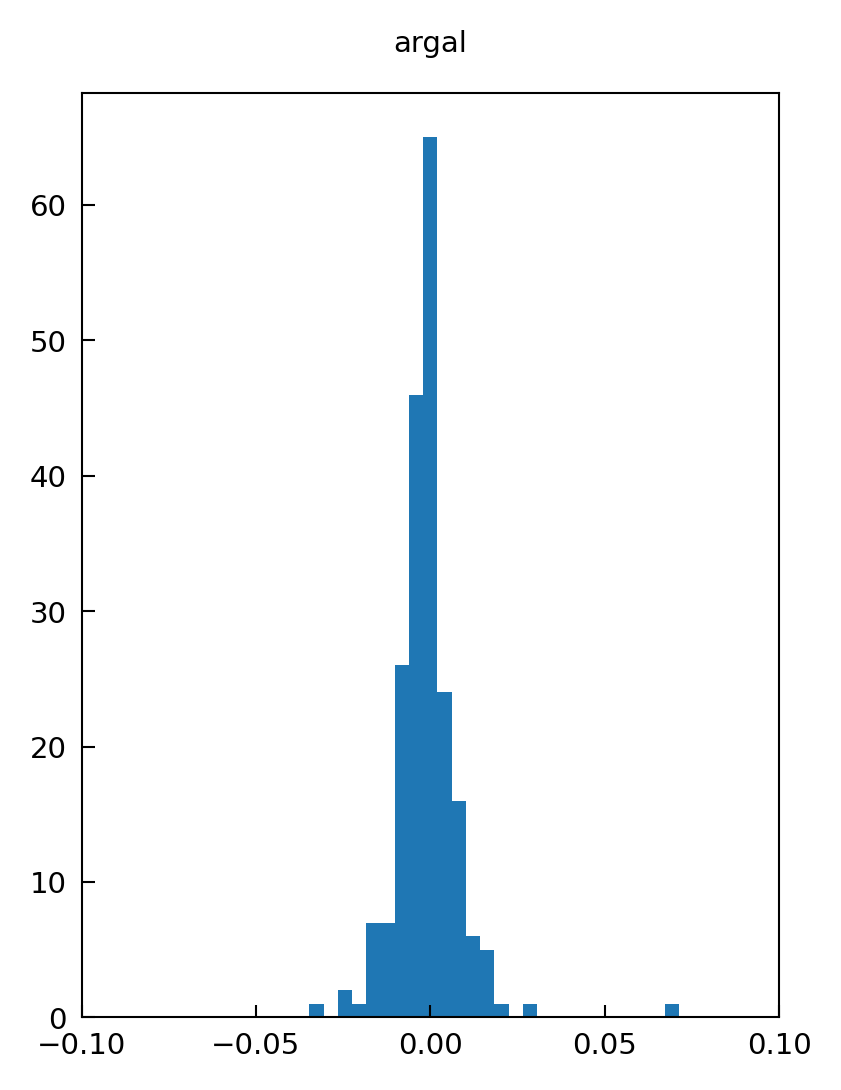

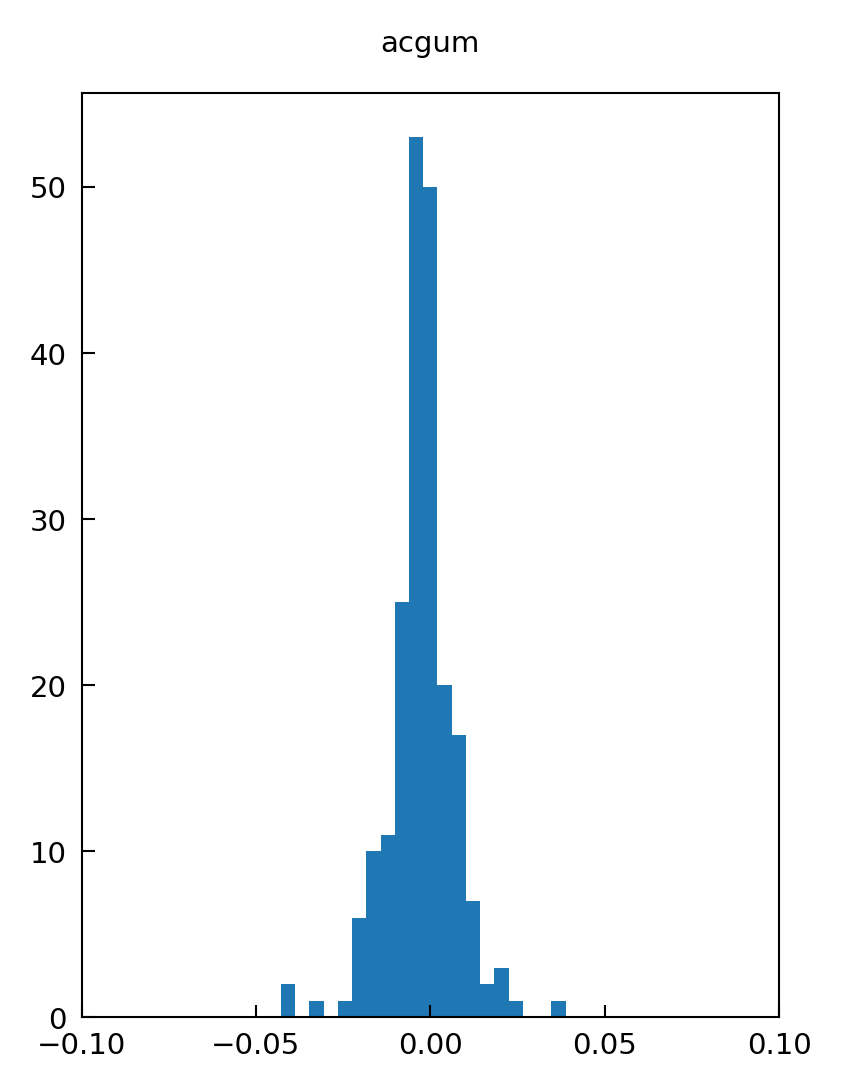

In [7]:
fibers = ['inulin', 'pectin', 'xylan', 'starch', 'argal', 'acgum']
interaction_mat = np.zeros([len(fibers), len(species)**2-len(species)])

for k, fiber in enumerate(fibers):
    # import fiber graph
    net_df = pd.read_csv(f"{fiber}_species_net_avg.csv")
    S2S = net_df[[s+"abs" for s in species]].values

    # ignore diagonal
    interactions = []
    interaction_names = []
    for i, sp_i in enumerate(species):
        for j, sp_j in enumerate(species):
            if i != j:
                interactions.append(S2S[i,j])
                interaction_names.append(sp_j+'>'+sp_i)
    interactions = np.array(interactions)
    interaction_names = np.array(interaction_names)
    interaction_mat[k] = interactions
    
    # plot histogram of species-species interactions
    bins = np.linspace(-.1, .1, 50)
    plt.hist(interactions, bins=bins)
    plt.title(fiber)
    plt.xlim([-.1, .1])
    plt.show()

In [8]:
# average interaction over fibers
int_avg = np.mean(interaction_mat, 0) 

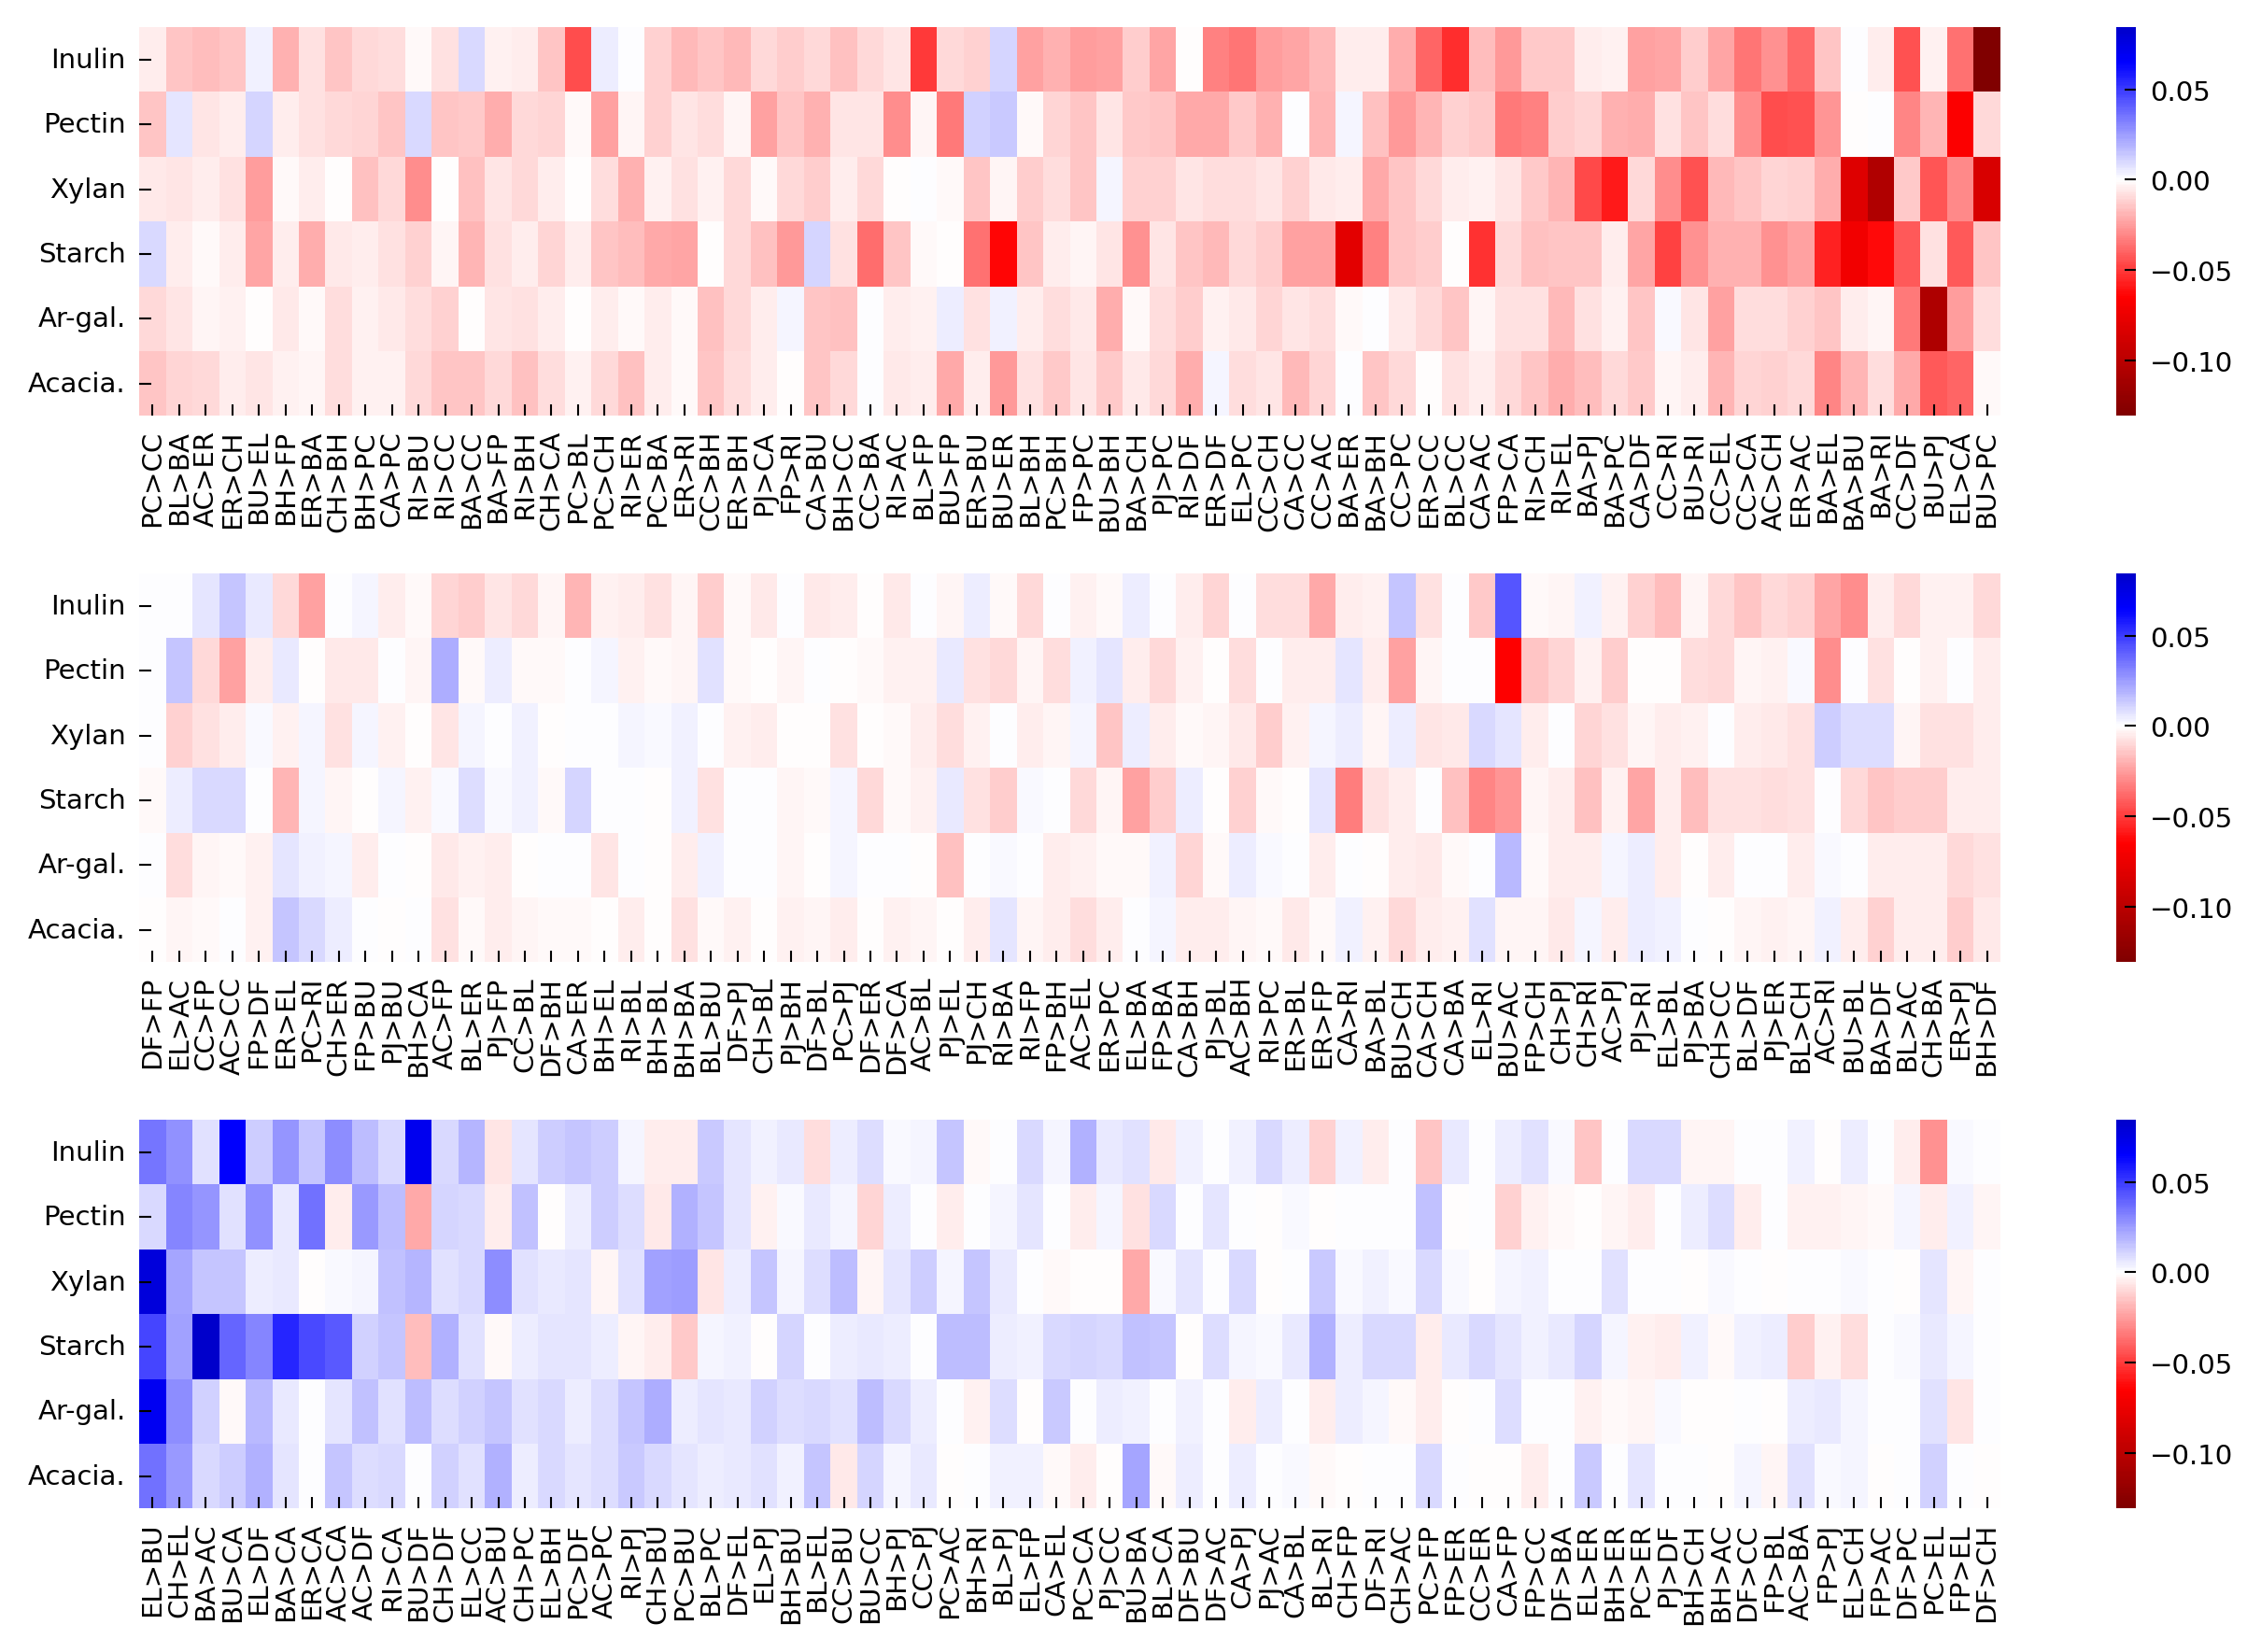

In [9]:
plt.figure(figsize=(9, 6))

plt.subplot(3, 1, 1)
sns.heatmap(interaction_mat[:, np.argsort(int_avg)][:, :70][:, ::-1], 
            xticklabels=interaction_names[np.argsort(int_avg)][:70][::-1],
            yticklabels=['Inulin', 'Pectin', 'Xylan', 'Starch', 'Ar-gal.', 'Acacia.'],
            cmap='seismic_r', 
            vmin=np.min(interaction_mat),
            vmax=np.max(interaction_mat),
            center=0.)

plt.subplot(3, 1, 2)
sns.heatmap(interaction_mat[:, np.argsort(int_avg)][:, 70:140][:, ::-1], 
            xticklabels=interaction_names[np.argsort(int_avg)][70:140][::-1],
            yticklabels=['Inulin', 'Pectin', 'Xylan', 'Starch', 'Ar-gal.', 'Acacia.'],
            cmap='seismic_r', 
            vmin=np.min(interaction_mat),
            vmax=np.max(interaction_mat),
            center=0.)

plt.subplot(3, 1, 3)
sns.heatmap(interaction_mat[:, np.argsort(int_avg)][:, 140:][:, ::-1], 
            xticklabels=interaction_names[np.argsort(int_avg)][140:][::-1],
            yticklabels=['Inulin', 'Pectin', 'Xylan', 'Starch', 'Ar-gal.', 'Acacia.'],
            cmap='seismic_r', 
            vmin=np.min(interaction_mat),
            vmax=np.max(interaction_mat),
            center=0.)

plt.tight_layout()
plt.savefig("../figures/motifs/pairwise_shap.svg", dpi=300)
plt.show()

In [10]:
# count number of times outgoing interactions switch
switch_counts = []

# count number of times outgoing interactions are the same over all fibers
same_counts = []

# loop over species
for sp in species:
    
    # index of outgoing interactions
    int_idx = []
    for int_name in interaction_names:
        if f'{sp}>' in int_name:
            int_idx.append(True)
        else:
            int_idx.append(False)
    int_idx = np.array(int_idx)
    
    # number of times that interactions are positive
    n_positive = np.sum(np.array(interaction_mat[:, int_idx]>0, int), 0)
    
    # index of interactions that change
    indices = np.where((n_positive > 0) & (n_positive < 6))[0]
    
    # count 
    switch_counts.append(len(indices))
    same_counts.append(14-len(indices))

# np array
switch_counts = np.array(switch_counts)
same_counts = np.array(same_counts)

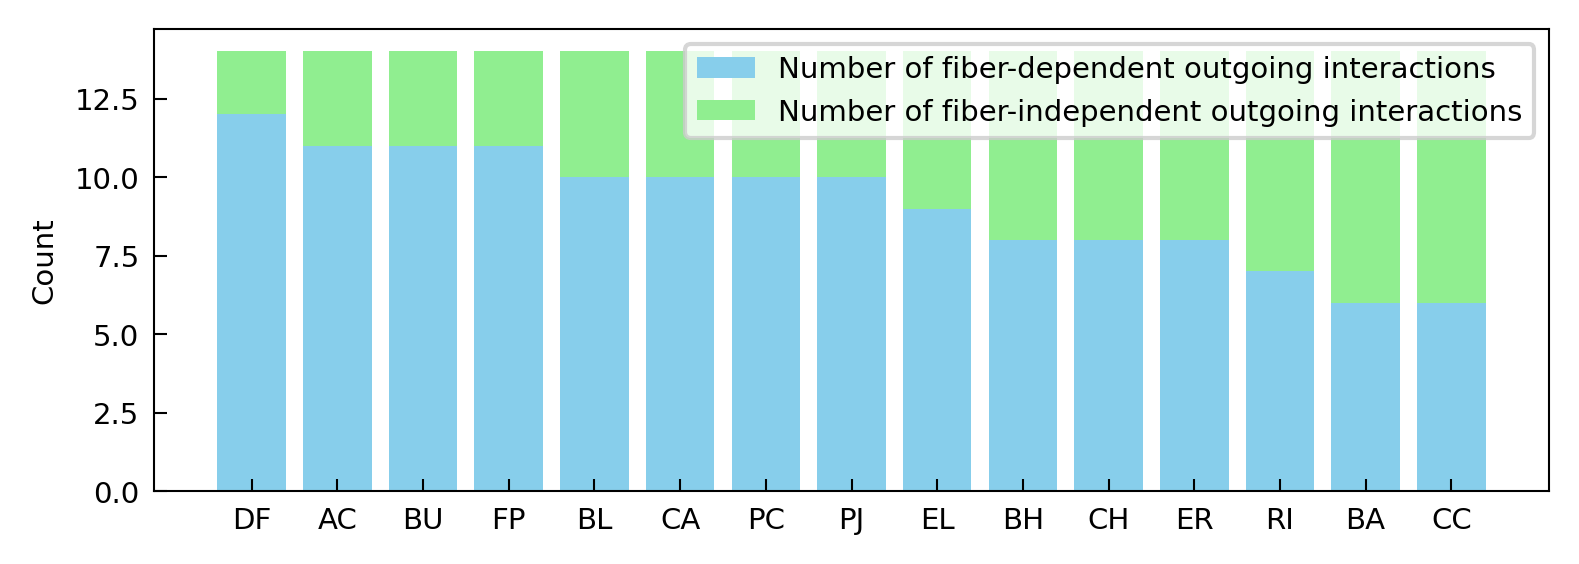

In [11]:
# Data
categories = np.array(species)[np.argsort(same_counts)]
values1 = switch_counts[np.argsort(same_counts)]
values2 = same_counts[np.argsort(same_counts)]

# Bar width
bar_width = 0.5

# Create bar plot
plt.figure(figsize=(6, 2))

# Plot bars
plt.bar(categories, values1, 
        color='skyblue', 
        label='Number of fiber-dependent outgoing interactions')
plt.bar(categories, values2, bottom=values1, 
        color='lightgreen', 
        label='Number of fiber-independent outgoing interactions')

# Add titles and labels
# plt.xlabel('Categories')
plt.ylabel('Count')

# Add legend
plt.legend()

# save
plt.savefig("../figures/motifs/interaction_frequency.svg", dpi=300)

# Show plot
plt.show()
